In [ ]:
'''Data Visualization III 
Download the Iris flower dataset or any other dataset into a DataFrame. (e.g., 
https://archive.ics.uci.edu/ml/datasets/Iris ). Scan the dataset and give the inference as: 
 
1. List down the features and their types (e.g., numeric, nominal) available in the dataset.  
2. Create a histogram for each feature in the dataset to illustrate the feature distributions.  
3. Create a boxplot for each feature in the dataset.  
4. Compare distributions and identify outliers.'''

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame from the dataset
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target variable (species) to the DataFrame
df['species'] = iris.target_names[iris.target]

# Display the first 5 rows of the DataFrame
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# List down the features and their types
print("Features and their types:")
for col in df.columns:
    if col != 'species': # Exclude the target variable for feature type analysis
        print(f"- {col}: Numeric (float64)")
    else:
        print(f"- {col}: Nominal (object)")

# Alternatively, using pandas dtypes
print("\nDataFrame dtypes:")
display(df.info())

Features and their types:
- sepal length (cm): Numeric (float64)
- sepal width (cm): Numeric (float64)
- petal length (cm): Numeric (float64)
- petal width (cm): Numeric (float64)
- species: Nominal (object)

DataFrame dtypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


None

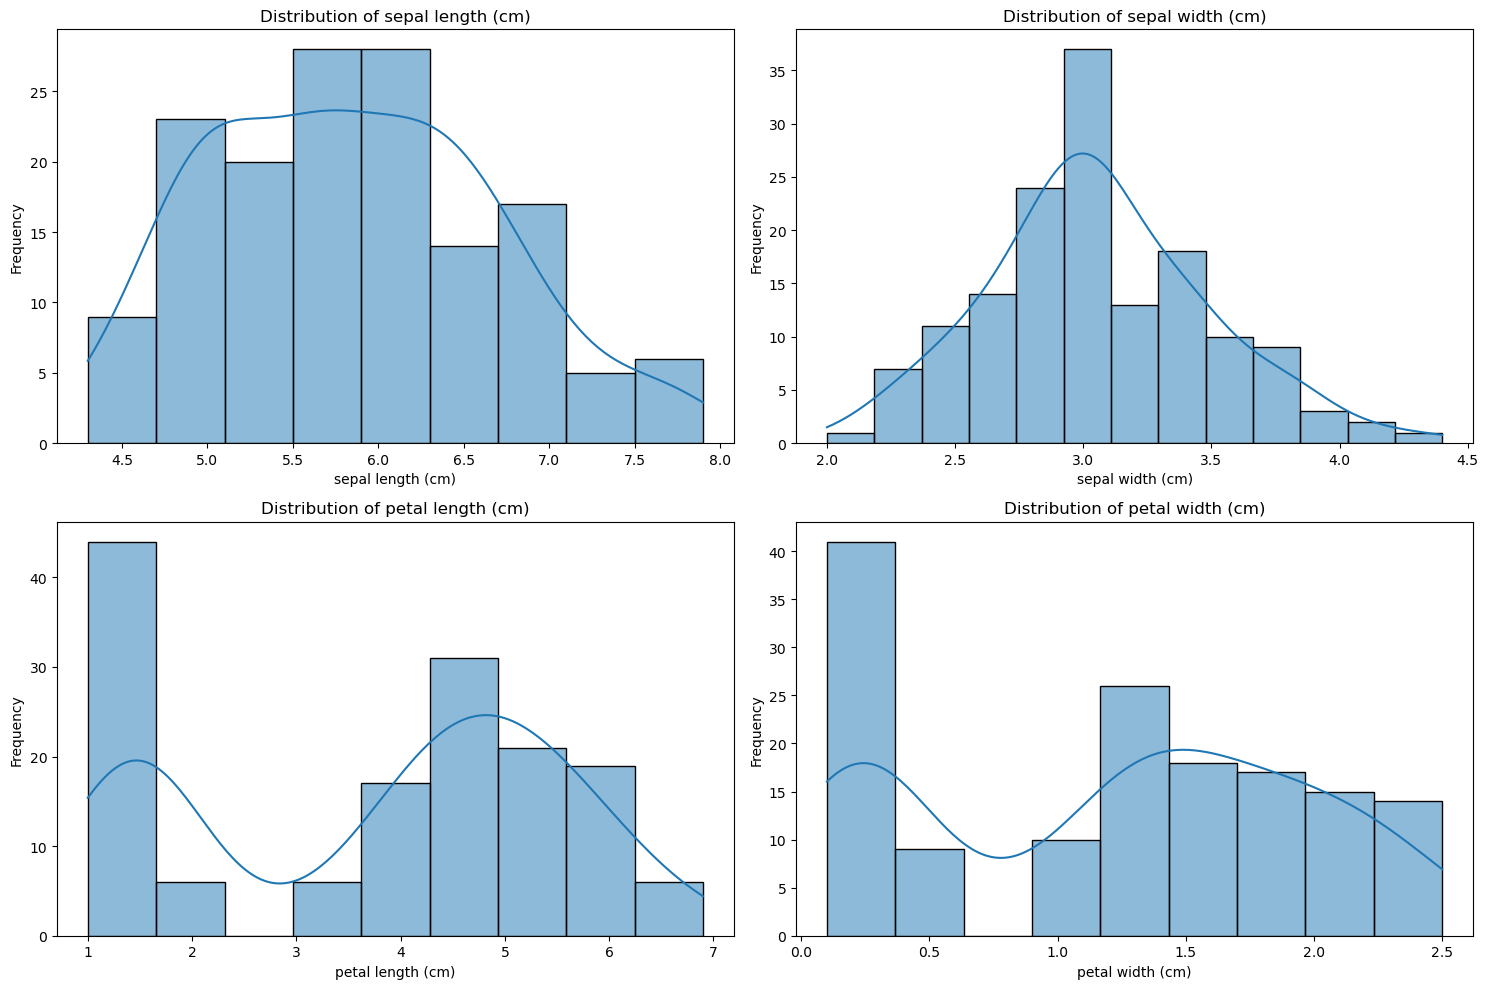

In [4]:
# Histograms for Each Feature
plt.figure(figsize=(15, 10))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    sns.histplot(df[feature], kde=True) # Plot histogram with KDE
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

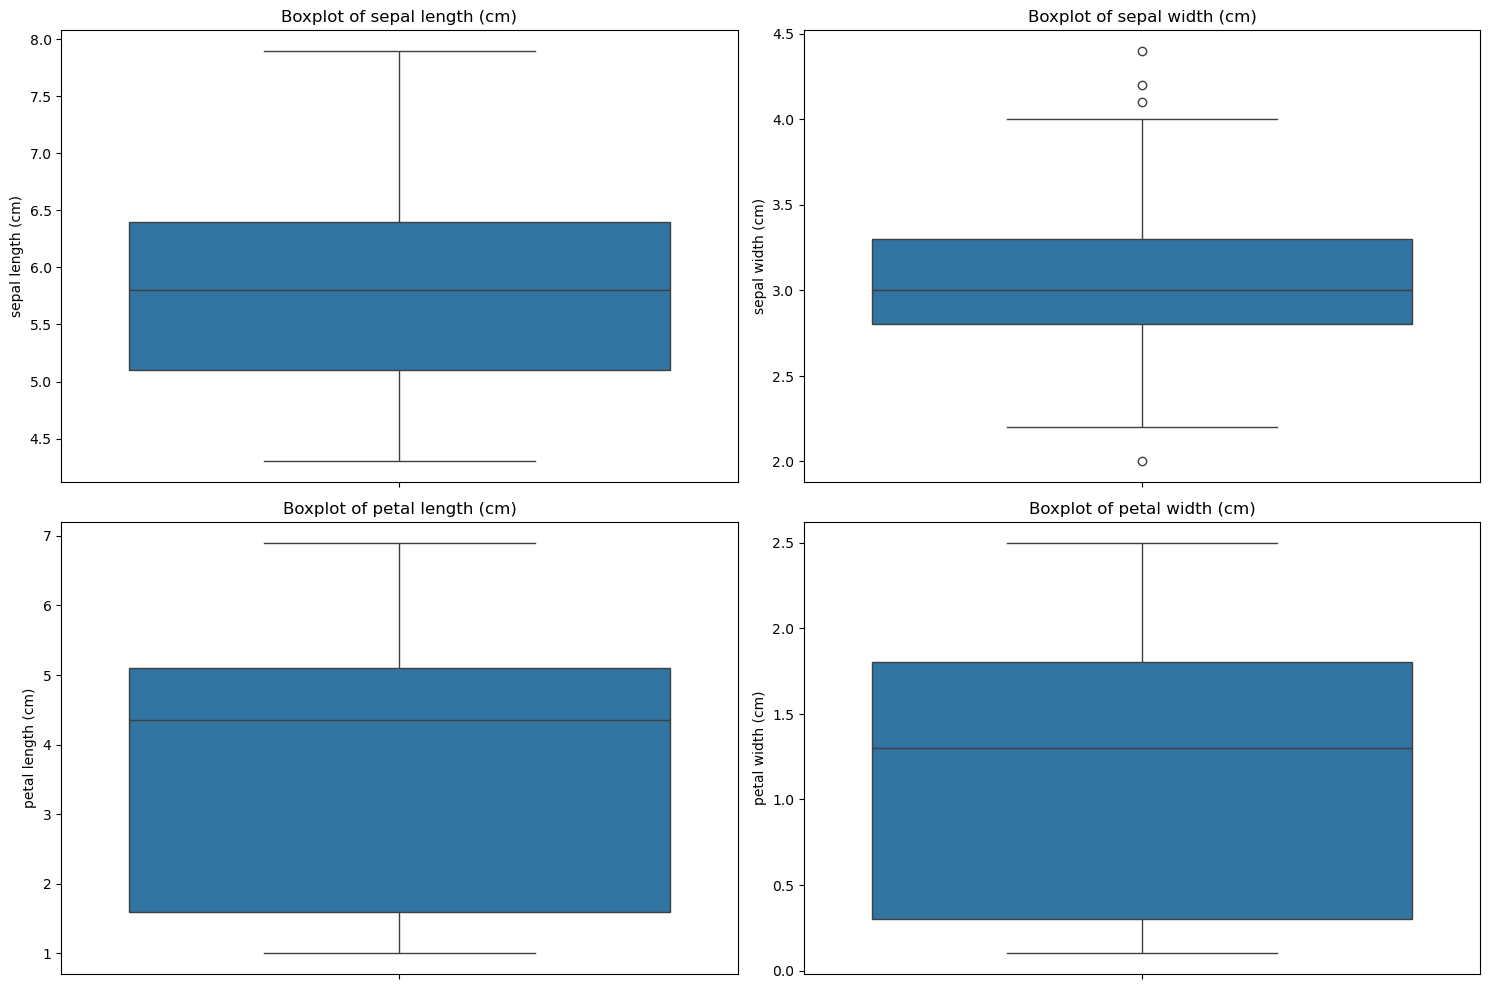

In [5]:
# Boxplots for Each Feature
plt.figure(figsize=(15, 10))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

In [6]:
# Outlier Detection using IQR Method
for feature in iris.feature_names:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]

    print(f"\n--- Outliers for {feature} ---")
    if not outliers.empty:
        display(outliers[['species', feature]])
        print(f"Number of outliers: {len(outliers)}")
    else:
        print("No outliers detected by IQR method.")


--- Outliers for sepal length (cm) ---
No outliers detected by IQR method.

--- Outliers for sepal width (cm) ---


,species,sepal width (cm)
15,setosa,4.4
32,setosa,4.1
33,setosa,4.2
60,versicolor,2.0


Number of outliers: 4

--- Outliers for petal length (cm) ---
No outliers detected by IQR method.

--- Outliers for petal width (cm) ---
No outliers detected by IQR method.


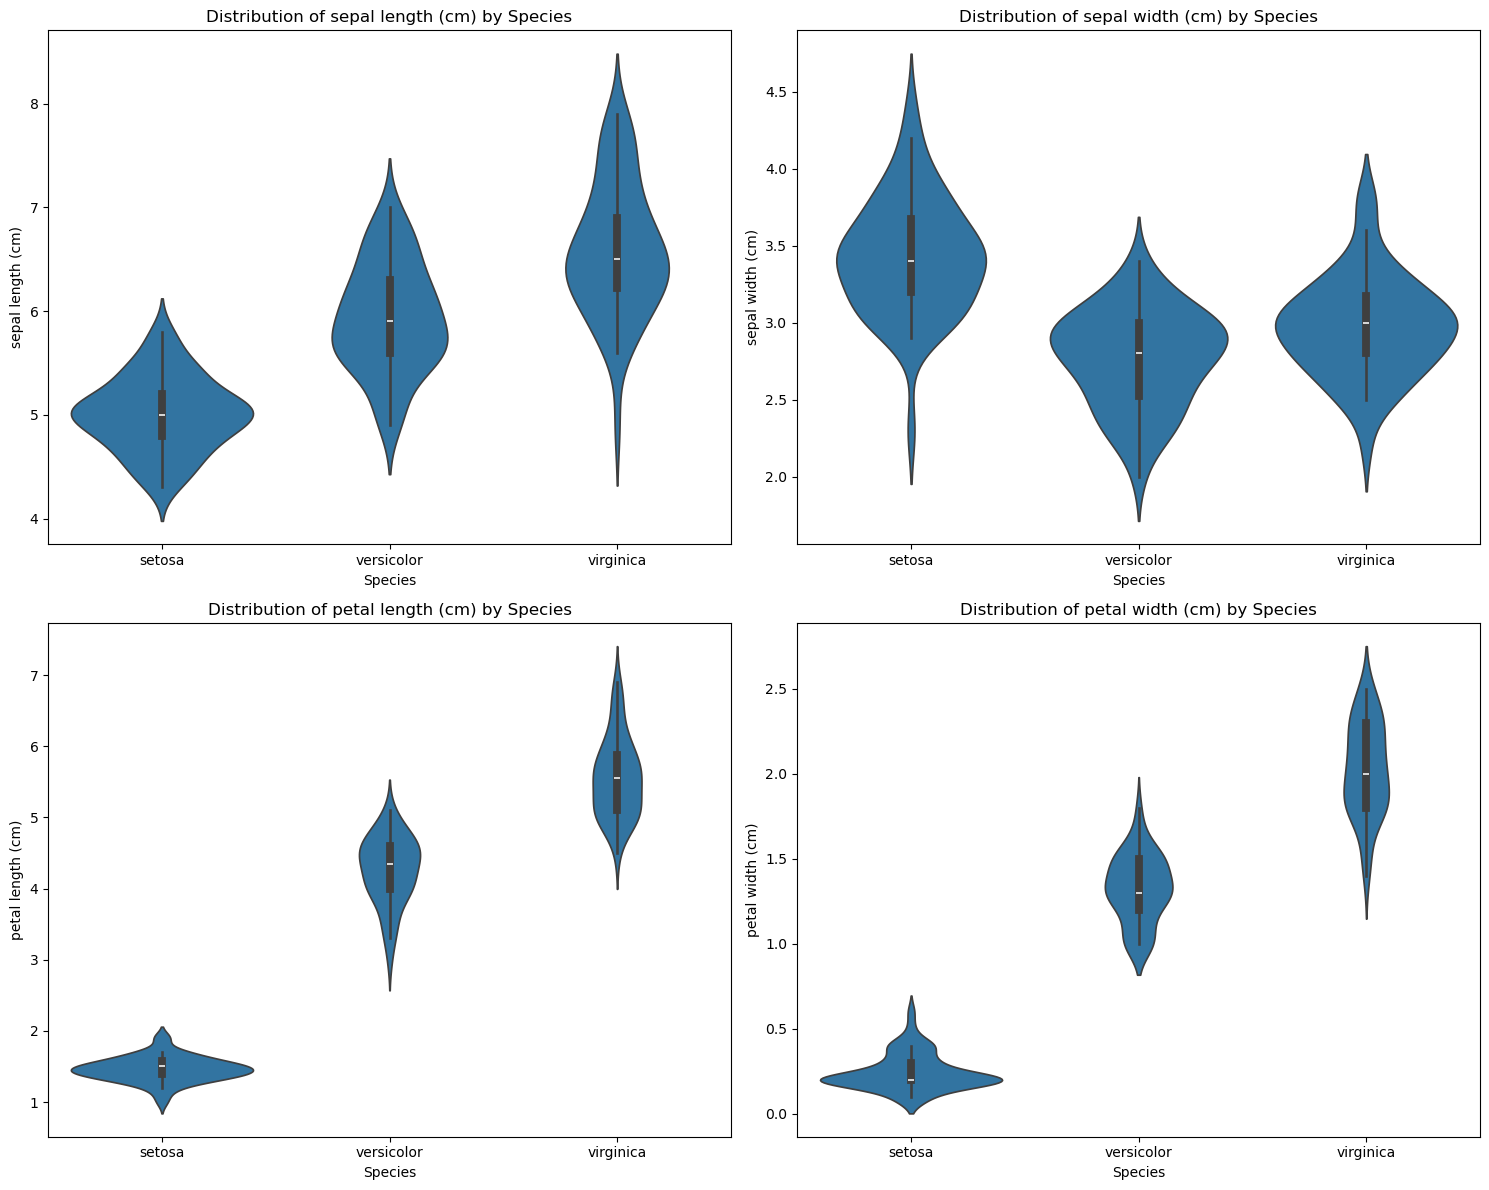

In [7]:
# Comparing Distributions by Species
plt.figure(figsize=(15, 12))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(x='species', y=feature, data=df)
    plt.title(f'Distribution of {feature} by Species')
    plt.xlabel('Species')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()